In [ ]:
import os
import zipfile
from google.colab import files

OUTDIR = "/content/figures_pdf"
os.makedirs(OUTDIR, exist_ok=True)

>>> Training Stage 1 (LSTM-DPO warm-up)...
 200th epoch Stage1 loss: -2.0933438905
 400th epoch Stage1 loss: -2.0825159046
 600th epoch Stage1 loss: -2.1027287068
 800th epoch Stage1 loss: -2.0828690101
1000th epoch Stage1 loss: -2.0849615576
1200th epoch Stage1 loss: -2.0813601144
1400th epoch Stage1 loss: -2.0905210084
1600th epoch Stage1 loss: -2.0616397894
1800th epoch Stage1 loss: -2.1077604252
2000th epoch Stage1 loss: -2.0964317876

>>> Evaluating Stage 2 with MC batch size = 64
    repeat  1/5 | RMSE=0.000495, MAE=0.000164, time=0.2833s
    repeat  2/5 | RMSE=0.000449, MAE=0.000176, time=0.2754s
    repeat  3/5 | RMSE=0.000436, MAE=0.000186, time=0.2763s
    repeat  4/5 | RMSE=0.000268, MAE=0.000097, time=0.2747s
    repeat  5/5 | RMSE=0.000461, MAE=0.000193, time=0.2784s

>>> Evaluating Stage 2 with MC batch size = 512
    repeat  1/5 | RMSE=0.000241, MAE=0.000110, time=0.3297s
    repeat  2/5 | RMSE=0.000125, MAE=0.000061, time=0.2852s
    repeat  3/5 | RMSE=0.000196, MAE=0.0

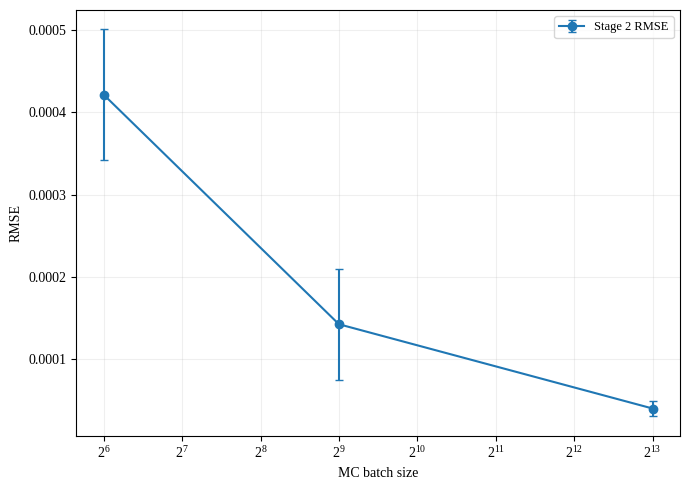

[Saved] /content/figures_pdf/stage2_mae_vs_mc_batch.pdf


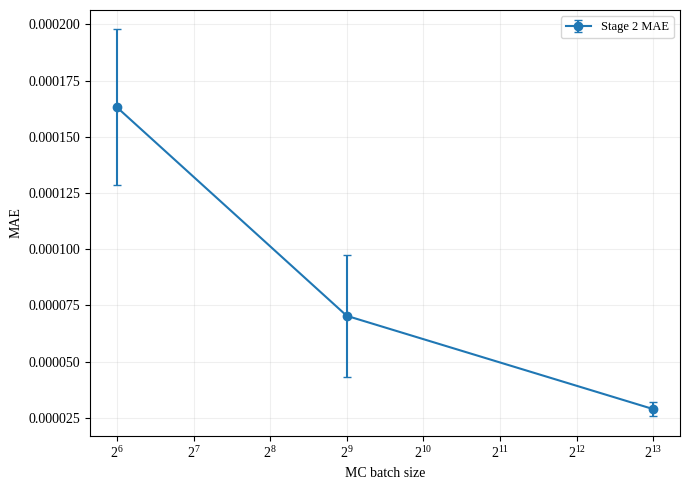

[Saved] /content/figures_pdf/stage2_runtime_vs_mc_batch.pdf


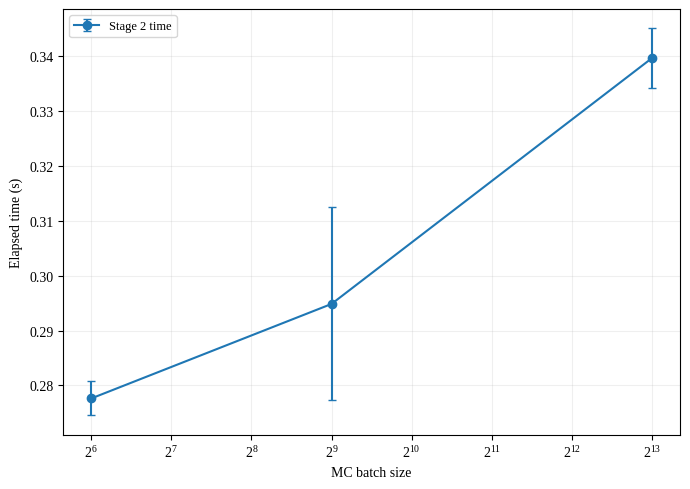

[Saved] /content/figures_pdf/control_paths_by_stage2_mc_batch.pdf


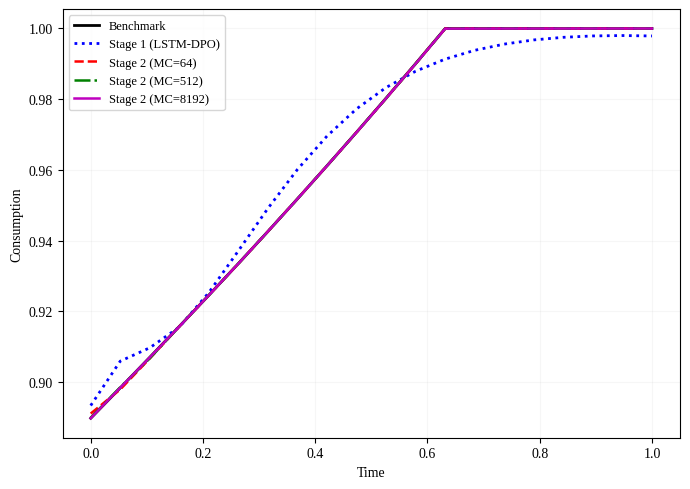

[ZIP saved] /content/figures_Batch_exp_pdf.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

plt.rcParams.update({
    "pdf.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Liberation Serif", "FreeSerif", "serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "mathtext.fontset": "stix",
})

# =============================================================================
# 0. Unified Configuration
# =============================================================================
CFG = {
    # reproducibility / device / dtype
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.float64,

    # problem params
    "alpha": 0.1,
    "beta": 0.2,
    "gamma": 0.5,
    "k_terminal": 1.0,
    "T": 1.0,
    "N": 20,
    "delta": 0.4,
    "X0": 1.0,

    # stage 1 training params
    "train_paths": 256,
    "hidden": 128,
    "lr": 3e-4,
    "n_iters": 2000,

    # stage 2 MC batch-size sweep
    "mc_batch_sizes": [64, 512, 8192],
    "mc_repeats": 5,

    # plotting
    "plot_stage2_batches": [64, 512, 8192],  # representative batch sizes to visualize
}

DEVICE = torch.device(CFG["device"])
torch.set_default_dtype(CFG["dtype"])


def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# =============================================================================
# 1. Physics (Dynamics / Utility)
# =============================================================================
class Physics:
    """Shared physics dynamics and utilities."""

    def __init__(self, cfg: dict):
        self.alpha = cfg["alpha"]
        self.beta = cfg["beta"]
        self.gamma = cfg["gamma"]
        self.k_term = cfg["k_terminal"]

        self.h = cfg["T"] / cfg["N"]
        self.delay_steps = int(round(cfg["delta"] / self.h))

    def step(self, x_now, x_lag, u, dW):
        drift = self.alpha * x_lag - u
        diff = self.beta * x_lag
        return x_now + drift * self.h + diff * dW

    def utility(self, u):
        return (u ** self.gamma) / self.gamma

    def get_terminal_reward(self, x_final):
        return self.k_term * x_final

    def init_history(self, batch_size: int, x0: float):
        return [
            torch.full((batch_size,), x0, device=DEVICE)
            for _ in range(self.delay_steps + 1)
        ]


# =============================================================================
# 2. Models
# =============================================================================
class BaseLSTM(nn.Module):
    def __init__(self, output_dim: int, hidden_dim: int):
        super().__init__()
        # policy input: (t, x_now), not x_lag
        self.lstm = nn.LSTM(2, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, t, x, hidden):
        inp = torch.stack([t, x], dim=1).unsqueeze(1)  # (B, 1, 2)
        out, new_hidden = self.lstm(inp, hidden)
        return self.fc(out[:, -1, :]), new_hidden


class PolicyNet(BaseLSTM):
    def __init__(self):
        super().__init__(output_dim=1, hidden_dim=CFG["hidden"])

    def forward(self, t, x, hidden):
        raw, h_new = super().forward(t, x, hidden)
        return torch.nn.functional.softplus(raw).squeeze(-1), h_new


# =============================================================================
# 3. Analytic Benchmark / Stage 1 / Stage 2
# =============================================================================
def solve_analytic():
    phy = Physics(CFG)
    p = np.zeros(CFG["N"] + 1)
    p[CFG["N"] - phy.delay_steps:] = CFG["k_terminal"]

    for i in range(CFG["N"] - phy.delay_steps - 1, -1, -1):
        p[i] = p[i + 1] + CFG["alpha"] * phy.h * p[i + 1 + phy.delay_steps]

    c_star = np.maximum(p, 1e-12) ** (1.0 / (CFG["gamma"] - 1.0))
    return c_star, p


def train_pg(policy: nn.Module, phy: Physics):
    print(">>> Training Stage 1 (LSTM-DPO warm-up)...")
    opt = optim.Adam(policy.parameters(), lr=CFG["lr"])

    for it in range(1, CFG["n_iters"] + 1):
        opt.zero_grad()

        dW = torch.randn(CFG["train_paths"], CFG["N"], device=DEVICE) * np.sqrt(phy.h)
        X = torch.zeros(CFG["train_paths"], CFG["N"] + phy.delay_steps + 1, device=DEVICE)
        X[:, : phy.delay_steps + 1] = CFG["X0"]

        run_util = 0.0
        hidden = None

        for n in range(CFG["N"]):
            k = phy.delay_steps + n
            t_val = torch.full((CFG["train_paths"],), n * phy.h, device=DEVICE)

            x_now = X[:, k]
            x_lag = X[:, n]

            # Policy receives only current state x_now, not x_lag.
            c_n, hidden = policy(t_val, x_now, hidden)

            # Dynamics still uses x_lag.
            X[:, k + 1] = phy.step(x_now, x_lag, c_n, dW[:, n])
            run_util += phy.utility(c_n) * phy.h

        loss = -(run_util + phy.get_terminal_reward(X[:, -1])).mean()
        if it % 200 == 0:
            print(f"{it:4d}th epoch Stage1 loss: {loss.item():.10f}")

        loss.backward()
        opt.step()

    return policy

def eval_pg_policy(policy: nn.Module, phy: Physics):
    c_pg = []

    with torch.no_grad():
        hidden = None
        X = phy.init_history(1, CFG["X0"])

        for i in range(CFG["N"]):
            k = phy.delay_steps + i
            t_i = torch.tensor([i * phy.h], device=DEVICE)

            x_now = X[k]
            x_lag = X[i]

            # Policy receives only current state x_now, not x_lag.
            c_i, hidden = policy(t_i, x_now, hidden)
            c_pg.append(float(c_i.item()))

            # Dynamics still uses x_lag.
            x_next = phy.step(x_now, x_lag, c_i, 0.0)
            X.append(x_next)

    return np.array(c_pg)

def sample_antithetic_dW(batch_size: int, h: float, device=DEVICE):
    """
    Antithetic Brownian increments with shape (batch_size,).

    If batch_size is even:
        [eps_1, ..., eps_m, -eps_1, ..., -eps_m]

    If batch_size is odd:
        one extra independent draw is appended.
    """
    half = batch_size // 2
    scale = np.sqrt(h)

    eps_half = torch.randn(half, device=device) * scale
    dW = torch.cat([eps_half, -eps_half], dim=0)

    if batch_size % 2 == 1:
        extra = torch.randn(1, device=device) * scale
        dW = torch.cat([dW, extra], dim=0)

    return dW

def compute_ppgdpo(base_policy: nn.Module, phy: Physics, mc_batch_size: int):
    """
    Stage 2 PGDPO with a user-specified Monte Carlo batch size.

    Policy input:
      - receives only (t, x_now)
      - does not receive x_lag directly

    Dynamics:
      - still uses x_lag

    Projection sampling:
      - uses antithetic Brownian increments
    """
    c_proj, p_proj = [], []

    real_hist = [torch.tensor([CFG["X0"]], device=DEVICE) for _ in range(phy.delay_steps + 1)]

    # real_hidden_hist[i] = hidden state available at the beginning of decision step i
    real_hidden_hist = [None]

    def _clone_hidden(hidden):
        if hidden is None:
            return None
        h, c = hidden
        return (h.detach().clone(), c.detach().clone())

    def _expand_hidden(hidden, batch_size: int):
        if hidden is None:
            return None
        h, c = hidden
        h = h.expand(-1, batch_size, -1).contiguous()
        c = c.expand(-1, batch_size, -1).contiguous()
        return (h, c)

    hidden_real = None
    t_start = time.perf_counter()

    for i in range(CFG["N"]):
        x_start = real_hist[-1].detach().clone().requires_grad_(True)
        n_inner = int(mc_batch_size)

        # stored hidden for current decision step i
        hidden_prefix = real_hidden_hist[i]
        hidden_inner = _expand_hidden(hidden_prefix, n_inner)

        # past state history for projection rollout
        past_hist = torch.stack(real_hist[:-1]).detach()
        past_hist = past_hist[-phy.delay_steps:]          # (delay_steps, 1)
        past_hist = past_hist.expand(-1, n_inner)         # (delay_steps, n_inner)

        curr_state = x_start.expand(n_inner)
        inner_X = [past_hist[k] for k in range(phy.delay_steps)] + [curr_state]

        J_future = 0.0

        for step in range(CFG["N"] - i):
            abs_step = i + step
            k_idx = phy.delay_steps + step
            t_val = torch.full((n_inner,), abs_step * phy.h, device=DEVICE)

            x_now = inner_X[k_idx]
            x_lag = inner_X[step]

            # Policy receives only current state x_now, not x_lag.
            c_val, hidden_inner = base_policy(t_val, x_now, hidden_inner)

            # Dynamics still uses x_lag, with antithetic Brownian increments.
            dW = sample_antithetic_dW(n_inner, phy.h, device=DEVICE)
            x_next = phy.step(x_now, x_lag, c_val, dW)

            inner_X.append(x_next)
            J_future = J_future + phy.utility(c_val) * phy.h

        J_total = J_future + phy.get_terminal_reward(inner_X[-1])
        grads = torch.autograd.grad(J_total.sum(), x_start)
        p_t = grads[0].item() / n_inner

        p_clamped = max(p_t, 1e-12)
        c_star = p_clamped ** (1.0 / (CFG["gamma"] - 1.0))

        c_proj.append(c_star)
        p_proj.append(p_t)

        # deterministic real rollout update
        t_real = torch.tensor([i * phy.h], device=DEVICE)
        x_now_real = real_hist[-1]
        x_lag_real = real_hist[-(phy.delay_steps + 1)]

        with torch.no_grad():
            # Hidden history is updated using only current state x_now_real.
            _, hidden_real = base_policy(t_real, x_now_real, hidden_real)

        x_next_real = phy.step(
            x_now_real,
            x_lag_real,
            torch.tensor([c_star], device=DEVICE),
            0.0,
        )

        real_hist.append(x_next_real)
        real_hidden_hist.append(_clone_hidden(hidden_real))

    elapsed = time.perf_counter() - t_start
    return np.array(c_proj), np.array(p_proj), elapsed


# =============================================================================
# 4. Metrics / Sweep / Plotting
# =============================================================================
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.mean((a - b) ** 2)))


def mae(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.mean(np.abs(a - b)))


def summarize_batch_sweep(gt, stage1_pred, batch_results):
    print("\n[Stage 1 performance]")
    print(f"  RMSE = {rmse(gt, stage1_pred):.6f}")
    print(f"  MAE  = {mae(gt, stage1_pred):.6f}")

    print("\n[Stage 2 batch-size sweep summary]")
    header = (
        f"{'MC batch':>10} | {'RMSE mean':>10} | {'RMSE std':>10} | "
        f"{'MAE mean':>10} | {'MAE std':>10} | {'Time mean (s)':>12} | {'Time std (s)':>12}"
    )
    print(header)
    print("-" * len(header))

    for bs in sorted(batch_results.keys()):
        item = batch_results[bs]
        print(
            f"{bs:10d} | "
            f"{item['rmse_mean']:10.9f} | {item['rmse_std']:10.9f} | "
            f"{item['mae_mean']:10.9f} | {item['mae_std']:10.9f} | "
            f"{item['time_mean']:12.6f} | {item['time_std']:12.6f}"
        )


def plot_stage2_batch_sweep(batch_results, save_dir=None):
    batch_sizes = sorted(batch_results.keys())
    rmse_means = [batch_results[bs]["rmse_mean"] for bs in batch_sizes]
    rmse_stds = [batch_results[bs]["rmse_std"] for bs in batch_sizes]
    mae_means = [batch_results[bs]["mae_mean"] for bs in batch_sizes]
    mae_stds = [batch_results[bs]["mae_std"] for bs in batch_sizes]
    time_means = [batch_results[bs]["time_mean"] for bs in batch_sizes]
    time_stds = [batch_results[bs]["time_std"] for bs in batch_sizes]

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    saved_paths = []

    # 1) RMSE figure
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(batch_sizes, rmse_means, yerr=rmse_stds, marker="o", capsize=3, label="Stage 2 RMSE")
    ax.set_xscale("log", base=2)
    ax.set_xlabel("MC batch size")
    ax.set_ylabel("RMSE")
    #ax.set_title("Stage 2 RMSE vs MC batch size")
    ax.grid(alpha=0.2)
    ax.legend()
    fig.tight_layout()

    if save_dir is not None:
        save_path = os.path.join(save_dir, "stage2_rmse_vs_mc_batch.pdf")
        fig.savefig(save_path, format="pdf", bbox_inches="tight")
        saved_paths.append(save_path)
        print(f"[Saved] {save_path}")

    plt.show()
    plt.close(fig)

    # 2) MAE figure
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(batch_sizes, mae_means, yerr=mae_stds, marker="o", capsize=3, label="Stage 2 MAE")
    ax.set_xscale("log", base=2)
    ax.set_xlabel("MC batch size")
    ax.set_ylabel("MAE")
    #ax.set_title("Stage 2 MAE vs MC batch size")
    ax.grid(alpha=0.2)
    ax.legend()
    fig.tight_layout()

    if save_dir is not None:
        save_path = os.path.join(save_dir, "stage2_mae_vs_mc_batch.pdf")
        fig.savefig(save_path, format="pdf", bbox_inches="tight")
        saved_paths.append(save_path)
        print(f"[Saved] {save_path}")

    plt.show()
    plt.close(fig)

    # 3) Runtime figure
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(batch_sizes, time_means, yerr=time_stds, marker="o", capsize=3, label="Stage 2 time")
    ax.set_xscale("log", base=2)
    ax.set_xlabel("MC batch size")
    ax.set_ylabel("Elapsed time (s)")
    #ax.set_title("Stage 2 runtime vs MC batch size")
    ax.grid(alpha=0.2)
    ax.legend()
    fig.tight_layout()

    if save_dir is not None:
        save_path = os.path.join(save_dir, "stage2_runtime_vs_mc_batch.pdf")
        fig.savefig(save_path, format="pdf", bbox_inches="tight")
        saved_paths.append(save_path)
        print(f"[Saved] {save_path}")

    plt.show()
    plt.close(fig)

    return saved_paths


def plot_control_comparison(t_grid, gt, c_stage1, representative_stage2, save_dir=None):
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(t_grid, gt, "k-", lw=2, label="Benchmark")
    ax.plot(t_grid, c_stage1, "b:", lw=2, label="Stage 1 (LSTM-DPO)")

    line_styles = ["r--", "g-.", "m-"]
    for ls, (bs, c_proj_mean) in zip(line_styles, representative_stage2.items()):
        ax.plot(t_grid, c_proj_mean, ls, lw=1.8, label=f"Stage 2 (MC={bs})")

    ax.set_xlabel("Time")
    ax.set_ylabel("Consumption")
    #ax.set_title("Control paths by Stage 2 MC batch size")
    ax.legend()
    ax.grid(alpha=0.1)

    fig.tight_layout()

    saved_path = None

    if save_dir is not None:
        saved_path = os.path.join(save_dir, "control_paths_by_stage2_mc_batch.pdf")
        fig.savefig(saved_path, format="pdf", bbox_inches="tight")
        print(f"[Saved] {saved_path}")

    plt.show()
    plt.close(fig)

    return saved_path


def evaluate_models():
    set_seed(CFG["seed"])
    phy = Physics(CFG)

    # 1) Analytic benchmark
    c_ana, _ = solve_analytic()
    gt = c_ana[:-1]

    # 2) Train Stage 1 once
    policy_pg = train_pg(PolicyNet().to(DEVICE), phy)
    c_stage1 = eval_pg_policy(policy_pg, phy)

    # 3) Sweep Stage 2 MC batch sizes
    batch_results = {}
    representative_stage2 = {}

    for bs in CFG["mc_batch_sizes"]:
        print(f"\n>>> Evaluating Stage 2 with MC batch size = {bs}")
        rmse_list, mae_list, time_list = [], [], []
        controls = []

        for rep in range(CFG["mc_repeats"]):
            set_seed(CFG["seed"] + 1000 * bs + rep)
            c_proj, p_proj, elapsed = compute_ppgdpo(policy_pg, phy, mc_batch_size=bs)

            rmse_val = rmse(gt, c_proj)
            mae_val = mae(gt, c_proj)

            rmse_list.append(rmse_val)
            mae_list.append(mae_val)
            time_list.append(elapsed)
            controls.append(c_proj)

            print(
                f"    repeat {rep + 1:2d}/{CFG['mc_repeats']} | "
                f"RMSE={rmse_val:.6f}, MAE={mae_val:.6f}, time={elapsed:.4f}s"
            )

        controls = np.stack(controls, axis=0)
        batch_results[bs] = {
            "rmse_mean": float(np.mean(rmse_list)),
            "rmse_std": float(np.std(rmse_list)),
            "mae_mean": float(np.mean(mae_list)),
            "mae_std": float(np.std(mae_list)),
            "time_mean": float(np.mean(time_list)),
            "time_std": float(np.std(time_list)),
            "control_mean": controls.mean(axis=0),
            "control_std": controls.std(axis=0),
        }

        if bs in CFG["plot_stage2_batches"]:
            representative_stage2[bs] = batch_results[bs]["control_mean"]

    # 4) Print summary
    summarize_batch_sweep(gt, c_stage1, batch_results)

    # 5) Plots
    t_grid = np.linspace(0, CFG["T"], CFG["N"])
    plot_stage2_batch_sweep(batch_results, save_dir=OUTDIR)
    plot_control_comparison(t_grid, gt, c_stage1, representative_stage2, save_dir=OUTDIR)

    return {
        "benchmark": gt,
        "stage1": c_stage1,
        "stage2_summary": batch_results,
    }


if __name__ == "__main__":
    results = evaluate_models()

    zip_path = "/content/figures_Batch_exp_pdf.zip"

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        for fname in os.listdir(OUTDIR):
            if fname.endswith(".pdf"):
                full_path = os.path.join(OUTDIR, fname)
                zipf.write(full_path, arcname=fname)

    print(f"[ZIP saved] {zip_path}")
    files.download(zip_path)
